# Musterlösung – Aufgabenblatt 8

## Mehrdimensionale Analysis – Partielle Ableitungen 1

In [6]:
# ── Imports & Setup ────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sympy import *
from mpl_toolkits.mplot3d import Axes3D

x, y, z, k = symbols('x y z k', real=True)
x1, x2, x3 = symbols('x1 x2 x3', real=True)

init_printing(use_latex='mathjax')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#0f0f1a',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'xtick.color':      '#888',
    'ytick.color':      '#888',
    'grid.color':       '#222',
    'grid.linewidth':   0.6,
    'text.color':       '#eee',
    'font.family':      'monospace',
    'figure.dpi':       120,
})

CYAN   = '#00e5ff'
ORANGE = '#ff6e3a'
GREEN  = '#39ff14'
PINK   = '#ff4fcf'

print('Setup fertig ✓')

Setup fertig ✓


---
## Aufgabe 1

$$f(x,y) = \frac{xy}{x^2+y^2}$$

### a) Definitionsbereich $D_f$

Der Nenner $x^2 + y^2 = 0$ genau dann, wenn $x = 0$ **und** $y = 0$.

$$\boxed{D_f = \mathbb{R}^2 \setminus \{(0,0)\}}$$

### b) Grenzwert $\lim_{(x,y)\to(0,0)} f(x,y)$ existiert nicht

Wir nähern uns dem Ursprung auf der Geraden $y = kx$ ($k \in \mathbb{R}$):

$$f(x, kx) = \frac{x \cdot kx}{x^2 + k^2 x^2} = \frac{k x^2}{x^2(1+k^2)} = \frac{k}{1+k^2}$$

Dieser Ausdruck **hängt von $k$ ab**. Zum Beispiel:

| Richtung $k$ | Grenzwert |
|:---:|:---:|
| $k=0$ (x-Achse) | $0$ |
| $k=1$ (Diagonale) | $\frac{1}{2}$ |
| $k=-1$ | $-\frac{1}{2}$ |

Da verschiedene Annäherungswege verschiedene Grenzwerte liefern, **existiert der Grenzwert nicht**. $\blacksquare$

### c) Niveaumenge $N_f(0) = \{(x,y) \mid f(x,y) = 0\}$

$$\frac{xy}{x^2+y^2} = 0 \quad \Leftrightarrow \quad xy = 0 \quad \text{(da } x^2+y^2 \neq 0\text{)}$$

$$xy = 0 \;\Leftrightarrow\; x = 0 \;\text{ oder }\; y = 0$$

$$\boxed{N_f(0) = \{(x,y) \in D_f \mid x=0 \text{ oder } y=0\} = \text{Koordinatenachsen ohne Ursprung}}$$

### d) Partielle Ableitungen an der Stelle $(1|2)$

Mit der Quotientenregel ($u = xy$, $v = x^2+y^2$):

**Nach $x$:**
$$\frac{\partial f}{\partial x} = \frac{y(x^2+y^2) - xy \cdot 2x}{(x^2+y^2)^2} = \frac{y^2-x^2}{\left(x^2+y^2\right)^2} \cdot y \cdot \frac{1}{y}$$

Einfacher direkt:
$$\frac{\partial f}{\partial x} = \frac{y(x^2+y^2) - 2x^2 y}{(x^2+y^2)^2} = \frac{y(y^2-x^2)}{(x^2+y^2)^2}$$

**An $(1,2)$:** $x^2+y^2 = 5$

$$\left.\frac{\partial f}{\partial x}\right|_{(1,2)} = \frac{2(4-1)}{25} = \frac{6}{25}$$

**Nach $y$** (analog, Symmetrie ergibt):
$$\frac{\partial f}{\partial y} = \frac{x(x^2-y^2)}{(x^2+y^2)^2}$$

$$\left.\frac{\partial f}{\partial y}\right|_{(1,2)} = \frac{1(1-4)}{25} = -\frac{3}{25}$$

$$\boxed{\nabla f(1,2) = \left(\frac{6}{25},\; -\frac{3}{25}\right)}$$


∂f/∂x = y*(-x**2 + y**2)/(x**2 + y**2)**2
∂f/∂y = x*(x**2 - y**2)/(x**2 + y**2)**2

∂f/∂x|(1,2) = 6/25 = 0.24
∂f/∂y|(1,2) = -3/25 = -0.12

f(x,kx) = k/(k**2 + 1)   (unabhängig von x → hängt von k ab!)


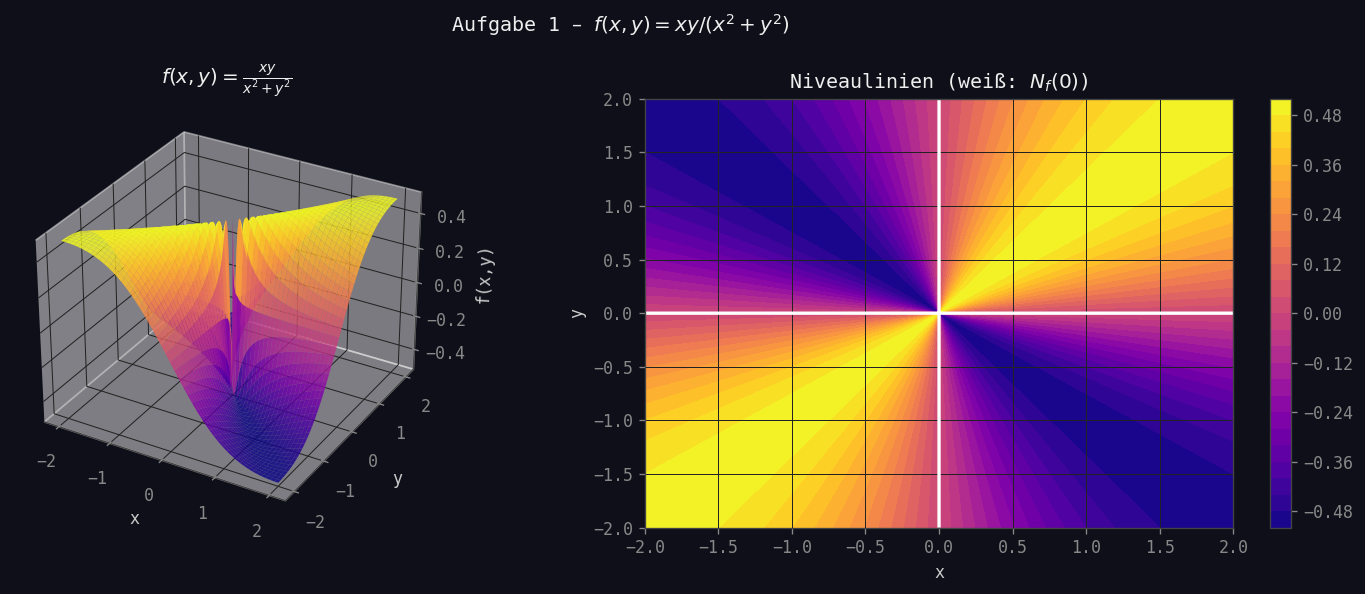

In [7]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
f1 = (x*y) / (x**2 + y**2)

# Partielle Ableitungen
df_dx = diff(f1, x)
df_dy = diff(f1, y)
print('∂f/∂x =', simplify(df_dx))
print('∂f/∂y =', simplify(df_dy))

# Werte an (1,2)
val_dx = df_dx.subs([(x, 1), (y, 2)])
val_dy = df_dy.subs([(x, 1), (y, 2)])
print('\n∂f/∂x|(1,2) =', val_dx, '=', float(val_dx))
print('∂f/∂y|(1,2) =', val_dy, '=', float(val_dy))

# Grenzwert auf Geraden y=kx
f_line = f1.subs(y, k*x)
lim_k = simplify(f_line)
print('\nf(x,kx) =', lim_k, '  (unabhängig von x → hängt von k ab!)')

# ── Plot ──────────────────────────────────────────────────────────────────────
x_np = np.linspace(-2, 2, 300)
y_np = np.linspace(-2, 2, 300)
X, Y = np.meshgrid(x_np, y_np)

# Maske für Ursprung
with np.errstate(divide='ignore', invalid='ignore'):
    denom = X**2 + Y**2
    denom[denom == 0] = np.nan
    Z = X*Y / denom

fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.set_facecolor('#0f0f1a')
surf = ax1.plot_surface(X, Y, Z, cmap='plasma', alpha=0.85, linewidth=0)
ax1.set(xlabel='x', ylabel='y', zlabel='f(x,y)',
        title=r'$f(x,y) = \frac{xy}{x^2+y^2}$')

ax2 = fig.add_subplot(122)
ax2.set_facecolor('#0f0f1a')
cp = ax2.contourf(X, Y, Z, levels=30, cmap='plasma')
fig.colorbar(cp, ax=ax2)
ax2.contour(X, Y, Z, levels=[0], colors='white', linewidths=2)
ax2.set(xlabel='x', ylabel='y', title=r'Niveaulinien (weiß: $N_f(0)$)')
ax2.grid(True)

plt.suptitle(r'Aufgabe 1 – $f(x,y) = xy/(x^2+y^2)$', fontsize=12)
plt.tight_layout()
plt.show()

---
## Aufgabe 2

### a) $f(x,y) = \cos(xy)$

#### Partielle Ableitungen

Mit der Kettenregel:

$$\frac{\partial f}{\partial x} = -\sin(xy) \cdot y = -y\sin(xy)$$

$$\frac{\partial f}{\partial y} = -\sin(xy) \cdot x = -x\sin(xy)$$

#### Gradientenvektor

$$\boxed{\nabla f = \begin{pmatrix} -y\sin(xy) \\ -x\sin(xy) \end{pmatrix}}$$

---

### b) $f(x,y) = \sin x\cos y - \sin y\cos x$

#### Vereinfachung erkennen

$$f(x,y) = \sin x \cos y - \cos x \sin y = \sin(x - y)$$

(Additionstheorem für den Sinus!)

#### Partielle Ableitungen

$$\frac{\partial f}{\partial x} = \cos(x-y) \cdot 1 = \cos(x-y)$$

$$\frac{\partial f}{\partial y} = \cos(x-y) \cdot (-1) = -\cos(x-y)$$

#### Gradientenvektor

$$\boxed{\nabla f = \begin{pmatrix} \cos(x-y) \\ -\cos(x-y) \end{pmatrix}}$$

**Beachte:** $\nabla f_x = -\nabla f_y$ für alle $(x,y)$, was die antisymmetrische Struktur von $\sin(x-y)$ widerspiegelt.


In [8]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
# a)
f2a = cos(x*y)
grad2a_x = diff(f2a, x)
grad2a_y = diff(f2a, y)
print('a) f(x,y) = cos(xy)')
print('   ∂f/∂x =', grad2a_x)
print('   ∂f/∂y =', grad2a_y)
print('   ∇f    =', Matrix([grad2a_x, grad2a_y]).T)

# b)
f2b = sin(x)*cos(y) - sin(y)*cos(x)
f2b_simp = trigsimp(f2b)
print('\nb) f(x,y) = sin(x)cos(y) - sin(y)cos(x)')
print('   Vereinfacht:', f2b_simp)

grad2b_x = diff(f2b, x)
grad2b_y = diff(f2b, y)
print('   ∂f/∂x =', trigsimp(grad2b_x))
print('   ∂f/∂y =', trigsimp(grad2b_y))
print('   ∇f    =', Matrix([trigsimp(grad2b_x), trigsimp(grad2b_y)]).T)

a) f(x,y) = cos(xy)
   ∂f/∂x = -y*sin(x*y)
   ∂f/∂y = -x*sin(x*y)
   ∇f    = Matrix([[-y*sin(x*y), -x*sin(x*y)]])

b) f(x,y) = sin(x)cos(y) - sin(y)cos(x)
   Vereinfacht: sin(x - y)
   ∂f/∂x = cos(x - y)
   ∂f/∂y = -cos(x - y)
   ∇f    = Matrix([[cos(x - y), -cos(x - y)]])


---
## Aufgabe 3

### a) $f(x,y,z) = e^{xyz}$

#### Partielle Ableitungen

Mit der Kettenregel ($u = xyz$, $f = e^u$):

$$\frac{\partial f}{\partial x} = e^{xyz} \cdot yz = yz\,e^{xyz}$$

$$\frac{\partial f}{\partial y} = e^{xyz} \cdot xz = xz\,e^{xyz}$$

$$\frac{\partial f}{\partial z} = e^{xyz} \cdot xy = xy\,e^{xyz}$$

#### Gradientenvektor

$$\boxed{\nabla f = e^{xyz}\begin{pmatrix} yz \\ xz \\ xy \end{pmatrix}}$$

---

### b) $f(x_1, x_2, x_3) = x_1^{x_2 + x_3}$

#### Umschreiben

$$f = x_1^{x_2+x_3} = e^{(x_2+x_3)\ln x_1}$$

#### Partielle Ableitungen

**Nach $x_1$** (Potenzfunktion mit variablem Exponent):
$$\frac{\partial f}{\partial x_1} = (x_2+x_3)\,x_1^{x_2+x_3-1}$$

**Nach $x_2$** (Exponentialfunktion in der Basis):
$$\frac{\partial f}{\partial x_2} = e^{(x_2+x_3)\ln x_1} \cdot \ln x_1 = x_1^{x_2+x_3}\ln x_1$$

**Nach $x_3$** (identisch mit $x_2$):
$$\frac{\partial f}{\partial x_3} = x_1^{x_2+x_3}\ln x_1$$

#### Gradientenvektor

$$\boxed{\nabla f = \begin{pmatrix} (x_2+x_3)\,x_1^{x_2+x_3-1} \\ x_1^{x_2+x_3}\ln x_1 \\ x_1^{x_2+x_3}\ln x_1 \end{pmatrix}}$$


In [9]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
# a)
f3a = exp(x*y*z)
grad3a = Matrix([diff(f3a, x), diff(f3a, y), diff(f3a, z)])
print('a) f(x,y,z) = exp(xyz)')
print('   ∂f/∂x =', diff(f3a, x))
print('   ∂f/∂y =', diff(f3a, y))
print('   ∂f/∂z =', diff(f3a, z))
print('   ∇f =')
pprint(grad3a)

# b)
x1p, x2p, x3p = symbols('x1 x2 x3', real=True, positive=True)
f3b = x1p**(x2p + x3p)
grad3b = Matrix([diff(f3b, x1p), diff(f3b, x2p), diff(f3b, x3p)])
grad3b_simp = Matrix([simplify(g) for g in grad3b])
print('\nb) f(x1,x2,x3) = x1^(x2+x3)')
print('   ∂f/∂x1 =', simplify(diff(f3b, x1p)))
print('   ∂f/∂x2 =', simplify(diff(f3b, x2p)))
print('   ∂f/∂x3 =', simplify(diff(f3b, x3p)))
print('   ∇f =')
pprint(grad3b_simp)

a) f(x,y,z) = exp(xyz)
   ∂f/∂x = y*z*exp(x*y*z)
   ∂f/∂y = x*z*exp(x*y*z)
   ∂f/∂z = x*y*exp(x*y*z)
   ∇f =
⎡     x⋅y⋅z⎤
⎢y⋅z⋅ℯ     ⎥
⎢          ⎥
⎢     x⋅y⋅z⎥
⎢x⋅z⋅ℯ     ⎥
⎢          ⎥
⎢     x⋅y⋅z⎥
⎣x⋅y⋅ℯ     ⎦

b) f(x1,x2,x3) = x1^(x2+x3)
   ∂f/∂x1 = x1**(x2 + x3 - 1)*(x2 + x3)
   ∂f/∂x2 = x1**(x2 + x3)*log(x1)
   ∂f/∂x3 = x1**(x2 + x3)*log(x1)
   ∇f =
⎡  x₂ + x₃ - 1          ⎤
⎢x₁           ⋅(x₂ + x₃)⎥
⎢                       ⎥
⎢     x₂ + x₃           ⎥
⎢   x₁       ⋅log(x₁)   ⎥
⎢                       ⎥
⎢     x₂ + x₃           ⎥
⎣   x₁       ⋅log(x₁)   ⎦


---
## Aufgabe 4

$$f(x_1, x_2, x_3) = \begin{pmatrix} \sqrt{x_1 x_2 x_3} \\ \sin(x_1 x_2 x_3) \end{pmatrix}$$

Die Jacobimatrix $\nabla f$ einer Abbildung $f: \mathbb{R}^3 \to \mathbb{R}^2$ ist eine $2 \times 3$-Matrix:

$$\nabla f = \begin{pmatrix}
\dfrac{\partial f_1}{\partial x_1} & \dfrac{\partial f_1}{\partial x_2} & \dfrac{\partial f_1}{\partial x_3} \\[10pt]
\dfrac{\partial f_2}{\partial x_1} & \dfrac{\partial f_2}{\partial x_2} & \dfrac{\partial f_2}{\partial x_3}
\end{pmatrix}$$

### Komponente $f_1 = \sqrt{x_1 x_2 x_3} = (x_1 x_2 x_3)^{1/2}$

Mit der Kettenregel ($u = x_1 x_2 x_3$):

$$\frac{\partial f_1}{\partial x_1} = \frac{1}{2\sqrt{x_1 x_2 x_3}} \cdot x_2 x_3 = \frac{x_2 x_3}{2\sqrt{x_1 x_2 x_3}} = \frac{\sqrt{x_2 x_3}}{2\sqrt{x_1}}$$

Durch Symmetrie:
$$\frac{\partial f_1}{\partial x_2} = \frac{x_1 x_3}{2\sqrt{x_1 x_2 x_3}}, \qquad \frac{\partial f_1}{\partial x_3} = \frac{x_1 x_2}{2\sqrt{x_1 x_2 x_3}}$$

### Komponente $f_2 = \sin(x_1 x_2 x_3)$

Mit der Kettenregel:

$$\frac{\partial f_2}{\partial x_1} = \cos(x_1 x_2 x_3) \cdot x_2 x_3$$

Durch Symmetrie:
$$\frac{\partial f_2}{\partial x_2} = x_1 x_3 \cos(x_1 x_2 x_3), \qquad \frac{\partial f_2}{\partial x_3} = x_1 x_2 \cos(x_1 x_2 x_3)$$

### Jacobimatrix

$$\boxed{\nabla f = \begin{pmatrix}
\dfrac{x_2 x_3}{2\sqrt{x_1 x_2 x_3}} & \dfrac{x_1 x_3}{2\sqrt{x_1 x_2 x_3}} & \dfrac{x_1 x_2}{2\sqrt{x_1 x_2 x_3}} \\[12pt]
x_2 x_3\cos(x_1 x_2 x_3) & x_1 x_3\cos(x_1 x_2 x_3) & x_1 x_2\cos(x_1 x_2 x_3)
\end{pmatrix}}$$

**Kompakter** lässt sich die zweite Zeile schreiben als $\cos(x_1 x_2 x_3)\cdot(x_2 x_3,\, x_1 x_3,\, x_1 x_2)$.


In [10]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
x1p, x2p, x3p = symbols('x1 x2 x3', real=True, positive=True)

f4_1 = sqrt(x1p * x2p * x3p)
f4_2 = sin(x1p * x2p * x3p)

# Jacobimatrix aufbauen
J = Matrix([
    [diff(f4_1, x1p), diff(f4_1, x2p), diff(f4_1, x3p)],
    [diff(f4_2, x1p), diff(f4_2, x2p), diff(f4_2, x3p)],
])

J_simp = Matrix([[simplify(e) for e in row] for row in J.tolist()])
print('Jacobimatrix ∇f (2×3):')
pprint(J_simp)

# Probe: Struktur sichtbar machen
print('\nZeile 1 (√(x1x2x3)-Ableitungen):')
for j, var in enumerate([x1p, x2p, x3p]):
    print(f'  ∂f1/∂x{j+1} =', simplify(diff(f4_1, var)))

print('\nZeile 2 (sin(x1x2x3)-Ableitungen):')
for j, var in enumerate([x1p, x2p, x3p]):
    print(f'  ∂f2/∂x{j+1} =', simplify(diff(f4_2, var)))

Jacobimatrix ∇f (2×3):
⎡     ____   ____          ____   ____          ____   ____   ⎤
⎢   ╲╱ x₂ ⋅╲╱ x₃         ╲╱ x₁ ⋅╲╱ x₃         ╲╱ x₁ ⋅╲╱ x₂    ⎥
⎢   ─────────────        ─────────────        ─────────────   ⎥
⎢         ____                 ____                 ____      ⎥
⎢     2⋅╲╱ x₁              2⋅╲╱ x₂              2⋅╲╱ x₃       ⎥
⎢                                                             ⎥
⎣x₂⋅x₃⋅cos(x₁⋅x₂⋅x₃)  x₁⋅x₃⋅cos(x₁⋅x₂⋅x₃)  x₁⋅x₂⋅cos(x₁⋅x₂⋅x₃)⎦

Zeile 1 (√(x1x2x3)-Ableitungen):
  ∂f1/∂x1 = sqrt(x2)*sqrt(x3)/(2*sqrt(x1))
  ∂f1/∂x2 = sqrt(x1)*sqrt(x3)/(2*sqrt(x2))
  ∂f1/∂x3 = sqrt(x1)*sqrt(x2)/(2*sqrt(x3))

Zeile 2 (sin(x1x2x3)-Ableitungen):
  ∂f2/∂x1 = x2*x3*cos(x1*x2*x3)
  ∂f2/∂x2 = x1*x3*cos(x1*x2*x3)
  ∂f2/∂x3 = x1*x2*cos(x1*x2*x3)
